### 1. Load PCA Data

In [1]:
import pandas as pd

df_pca = pd.read_csv("../data/processed/pca_data.csv")

df_pca.head()

,0,1,2,3,4,5,6,7,8
0,-0.032142,0.746922,-0.034809,1.655687,-0.950185,-0.135561,0.091160,-0.870511,-0.742752
1,0.011877,0.234871,-0.013761,0.625494,-1.200336,-0.164041,0.065241,-0.686634,-1.380668
2,0.005977,0.265991,-0.013549,0.818996,-1.212434,-0.429343,0.056837,-0.563511,-1.193267
3,-0.000794,0.385131,-0.020377,0.917972,-1.124938,-0.135807,0.073557,-0.750355,-1.205183
4,-0.031575,0.701026,-0.032324,1.699842,-1.000742,-0.415228,0.078570,-0.715290,-0.643732


### 2. Elbow Method

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(df_pca)

    inertia.append(model.inertia_)

### 3. Plot Elbow

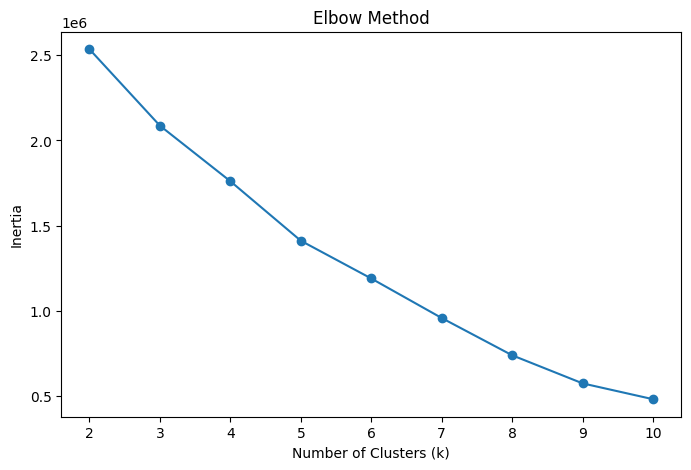

In [3]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

- Nhận xét Elbow

- Đồ thị bắt đầu giảm chậm từ khoảng k=5.
- Chọn k=5 để cân bằng giữa độ chính xác và độ phức tạp mô hình.

### 4. Train Kmeans
- KMeans Clustering

In [4]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(df_pca)

### 5. Silhouette Score

In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    df_pca,
    clusters,
    sample_size=10000,
    random_state=42
)

print("Silhouette Score:", score)

Silhouette Score: 0.43595111429491906


- Nhận xét Silhouette
    - Silhouette Score khoảng 0.45.
    - Điều này cho thấy mô hình phân cụm ở mức khá tốt.
    - Các cluster có sự tách biệt tương đối rõ ràng.

### 6. Visualization - Cluster Visualization

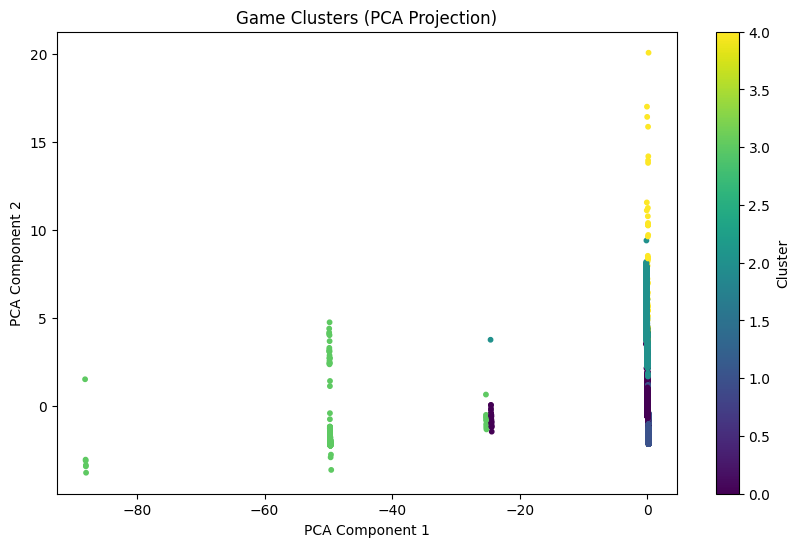

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_pca.iloc[:, 0],
    df_pca.iloc[:, 1],
    c=clusters,
    cmap='viridis',
    s=10
)

plt.title("Game Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label='Cluster')

plt.show()

### 7. Load Raw Data

In [7]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(".."))
from src.db_connection import get_engine
engine = get_engine()

df_cluster = pd.read_sql("""
SELECT *
FROM vw_applications_ml_base
WHERE name IS NOT NULL
  AND TRIM(name) <> ''
ORDER BY appid
""", engine)

print("Metadata rows:", len(df_cluster))
df_cluster.head()

Metadata rows: 239660


,appid,name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,created_at,updated_at
0,10,Counter-Strike,game,0,0,2000-11-01,88.0,161854.0,999.0,999.0,0.0,USD,NaN,1,1,1,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,0,0,1999-04-01,NaN,6633.0,499.0,499.0,0.0,USD,NaN,1,1,1,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,0,0,2003-05-01,79.0,4308.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,0,0,2001-06-01,NaN,2338.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,0,0,1999-11-01,NaN,22793.0,499.0,499.0,0.0,USD,NaN,1,1,1,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


In [8]:
print("PCA rows:", len(df_pca))
print("Cluster labels:", len(clusters))
print("Metadata rows:", len(df_cluster))

PCA rows: 239660
Cluster labels: 239660
Metadata rows: 239660


In [9]:
df_cluster["cluster"] = clusters
df_cluster.head()

,appid,name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,...,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,created_at,updated_at,cluster
0,10,Counter-Strike,game,0,0,2000-11-01,88.0,161854.0,999.0,999.0,...,USD,NaN,1,1,1,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,0
1,20,Team Fortress Classic,game,0,0,1999-04-01,NaN,6633.0,499.0,499.0,...,USD,NaN,1,1,1,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,0
2,30,Day of Defeat,game,0,0,2003-05-01,79.0,4308.0,499.0,499.0,...,USD,NaN,1,1,1,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,0
3,40,Deathmatch Classic,game,0,0,2001-06-01,NaN,2338.0,499.0,499.0,...,USD,NaN,1,1,1,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,0
4,50,Half-Life: Opposing Force,game,0,0,1999-11-01,NaN,22793.0,499.0,499.0,...,USD,NaN,1,1,1,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,0


### 8. Cluster Distribution

In [10]:
df_cluster['cluster'].value_counts()

cluster
0    188240
1     36787
2     14291
3       272
4        70
Name: count, dtype: int64

### 9. Cluster Summary

In [11]:
cluster_summary = df_cluster.groupby('cluster')[[
    'metacritic_score',
    'recommendations_total',
    'mat_initial_price',
    'mat_achievement_count'
]].mean()

cluster_summary

,metacritic_score,recommendations_total,mat_initial_price,mat_achievement_count
cluster,,,,
0,73.925179,4265.109959,6.190059e+03,31.741777
1,74.411765,35972.830303,4.929069e+04,40.728814
2,74.918831,5039.455211,8.730577e+03,57.302329
3,72.200000,1622.342857,7.486154e+02,23.760417
4,76.875000,27595.837838,3.338122e+07,49.277778


### 10. Sample Games
- Sample Games in Each Cluster

In [12]:
for i in range(5):
    print(f"\n========== CLUSTER {i} ==========")

    display(
        df_cluster[df_cluster['cluster'] == i][[
            'name',
            'type',
            'is_free',
            'metacritic_score',
            'recommendations_total',
            'mat_initial_price'
        ]].head(10)
    )


========== CLUSTER 0 ==========


,name,type,is_free,metacritic_score,recommendations_total,mat_initial_price
0,Counter-Strike,game,0,88.0,161854.0,999.0
1,Team Fortress Classic,game,0,NaN,6633.0,499.0
2,Day of Defeat,game,0,79.0,4308.0,499.0
3,Deathmatch Classic,game,0,NaN,2338.0,499.0
4,Half-Life: Opposing Force,game,0,NaN,22793.0,499.0
5,Ricochet,game,0,NaN,4371.0,499.0
6,Half-Life,game,0,96.0,107092.0,999.0
8,Half-Life: Blue Shift,game,0,71.0,16808.0,499.0
9,Half-Life 2: Demo,demo,1,96.0,NaN,NaN
10,Half-Life 2,game,0,96.0,184698.0,999.0



========== CLUSTER 1 ==========


,name,type,is_free,metacritic_score,recommendations_total,mat_initial_price
27,Counter-Strike 2,game,1,NaN,4661011.0,NaN
62,DOOM + DOOM II,game,0,NaN,22658.0,4999.0
95,Jagged Alliance 2: Unfinished Business,NaN,0,NaN,NaN,NaN
109,Bejeweled 2 Deluxe Free Demo,demo,1,NaN,NaN,NaN
111,Chuzzle Deluxe Free Demo,demo,1,NaN,NaN,NaN
113,Insaniquarium Deluxe Free Demo,demo,1,NaN,NaN,NaN
115,Zuma Deluxe Free Demo,demo,1,NaN,NaN,NaN
117,AstroPop Deluxe Free Demo,demo,1,NaN,NaN,NaN
119,Bejeweled Deluxe Free Demo,demo,1,NaN,NaN,NaN
121,Big Money! Deluxe Free Demo,demo,1,NaN,NaN,NaN



========== CLUSTER 2 ==========


,name,type,is_free,metacritic_score,recommendations_total,mat_initial_price
29,Red Orchestra: Ostfront 41-45,game,0,81.0,1471.0,499.0
46,Jagged Alliance 2 Gold,game,0,NaN,NaN,1999.0
54,Earth 2160,game,0,73.0,729.0,999.0
56,Two Worlds Epic Edition,game,0,65.0,2516.0,1499.0
70,Gumboy - Crazy Adventures™,game,0,69.0,106.0,499.0
96,FlatOut 2,game,0,76.0,16794.0,999.0
98,Call of Juarez,game,0,72.0,3344.0,999.0
105,Safecracker: The Ultimate Puzzle Adventure,game,0,69.0,431.0,499.0
164,Sniper Elite,game,0,76.0,3336.0,799.0
182,Garry's Mod,game,0,NaN,1013561.0,999.0



========== CLUSTER 3 ==========


,name,type,is_free,metacritic_score,recommendations_total,mat_initial_price
7,Counter-Strike: Condition Zero,game,0,65.0,20113.0,999.0
15,Half-Life 2: Lost Coast,game,0,NaN,10645.0,NaN
25,Alien Swarm,game,1,77.0,299.0,NaN
26,Portal 2 Sixense MotionPack DLC,dlc,0,NaN,NaN,NaN
28,Rag Doll Kung Fu,game,0,69.0,NaN,99.0
32,Killing Floor Outbreak Character Pack,dlc,0,NaN,NaN,799.0
55165,Mortal Kombat 11 Cangaceiro Kano,dlc,1,NaN,NaN,NaN
80603,Griddlers TED and PET,game,0,NaN,NaN,499.0
80604,Fairytale Mosaics Cinderella,game,0,NaN,NaN,499.0
80605,Pirate Jigsaw,game,0,NaN,NaN,499.0



========== CLUSTER 4 ==========


,name,type,is_free,metacritic_score,recommendations_total,mat_initial_price
6694,METAL GEAR SOLID V: GROUND ZEROES,game,0,80.0,12804.0,19999900.0
6760,Sniper Elite 4,game,0,78.0,51667.0,38999900.0
6899,Suicide Squad: Kill the Justice League,game,0,NaN,11136.0,89900000.0
8201,Deus Ex: Mankind Divided,game,0,83.0,29716.0,32500000.0
8848,InnerSpace,game,0,65.0,152.0,26000000.0
8852,Pro Basketball Manager 2016,game,0,NaN,NaN,16500000.0
8854,Dying Light - Ultimate Survivor Bundle,dlc,0,NaN,611.0,41250000.0
8902,Caromble!,game,0,NaN,NaN,18000000.0
8912,Ghost Song,game,0,79.0,900.0,22650000.0
8995,NARUTO SHIPPUDEN: Ultimate Ninja STORM 4,game,0,NaN,71166.0,19900000.0


### 11. Final Conclusion

- Thuật toán KMeans Clustering được áp dụng với số cụm k = 5.
- PCA được sử dụng để giảm số chiều dữ liệu nhưng vẫn giữ lại khoảng 95% thông tin quan trọng.
- Mô hình đạt Silhouette Score khoảng 0.45, cho thấy chất lượng phân cụm ở mức khá tốt.
- Các cluster thể hiện những nhóm game Steam có đặc điểm khác nhau như:
  - game miễn phí (free-to-play)
  - game được đề xuất nhiều
  - game giá cao / chất lượng cao
  - game indie hoặc niche
- Việc phân cụm giúp khám phá các mẫu tiềm ẩn trong dữ liệu và hỗ trợ phân tích hành vi, đặc điểm của các nhóm game trên Steam.
- Kết quả này có thể hỗ trợ cho các bài toán recommendation system, phân tích thị trường game hoặc nghiên cứu hành vi người dùng.